In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits
import healpy as hp

import pandas as pd

from scipy.interpolate import interp1d
from scipy import optimize
from scipy.stats import poisson
from scipy import signal

sys.path.append('..')

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [15]:
%%html
<style>
.dataframe th {font-size: 18px;}
.dataframe td {font-size: 16px;}
</style>

## 1. Build masks

In [6]:
# masks
mask_ps = np.load("data/fermidata_pscmask_512.npy") == 1

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_square = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=False, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

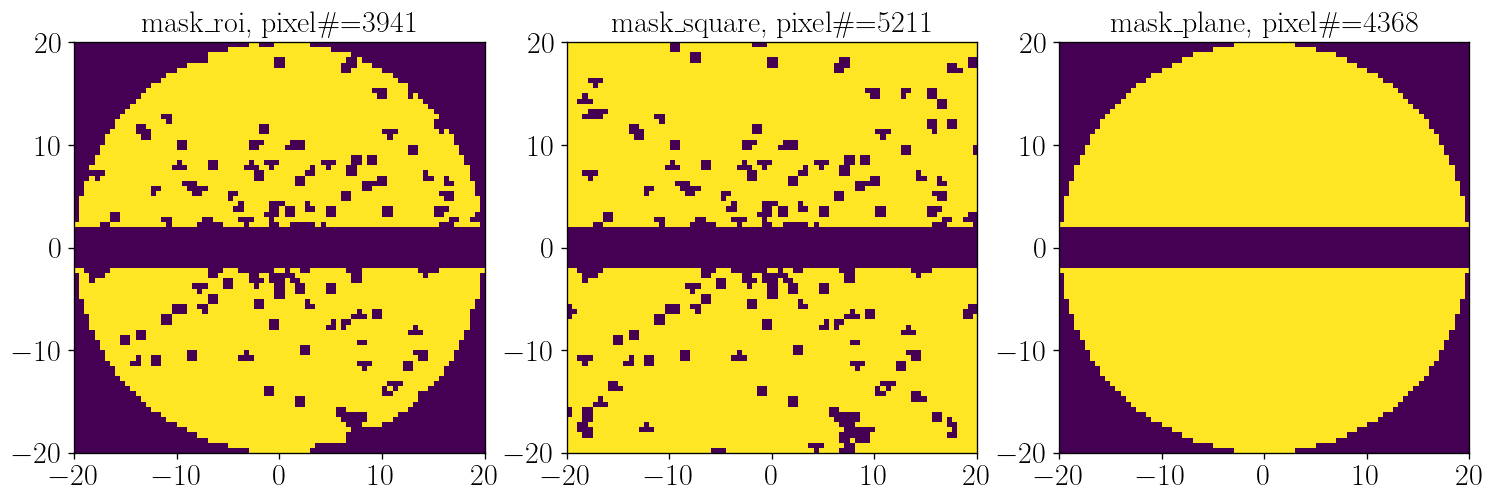

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
for i, (name, m) in enumerate(zip(['mask_roi', 'mask_square', 'mask_plane'], [mask_roi, mask_square, mask_plane])):
    axs[i].imshow(~m, extent=(-20,20,-20,20))
    axs[i].set(title=f'{name}, pixel\#={np.sum(~m)}')
    #axs[i].set(xlabel='l [deg]', ylabel='b [deg]')

## 2. Poisson fits

In [8]:
def likelihood(theta, data, tmpls, mask=None):
    """ Pixel-wise product Poisson log-likelihood
    """ 
    if mask is None:
        mask = np.zeros_like(tmpls[0], dtype=bool)
    tmpl_sum = np.einsum("ij,i -> j", tmpls[:, ~mask], theta)
    return - poisson.logpmf(data[~mask], tmpl_sum).mean()

In [9]:
# load counts
counts = np.load('data/counts_573week.npy')

In [29]:
# Do fits for p6, Model O, and SkyFACT
diff_models = {
    'p6v11': ['p6v11'],
    'ccwa' : ['ccwaics', 'ccwapibrem'],
    'ccwf' : ['ccwfics', 'ccwfpibrem']
}
other_tmpls = ['gce', 'psc', 'iso', 'bub']

columns = ['model', 'LL'] + other_tmpls + ['diff1', 'diff2']
entrys = []

for m, diff_tmpls in diff_models.items():
    tmpl_tags = other_tmpls + diff_tmpls
    tmpls = np.array([temp[k] for k in tmpl_tags])
    bounds = tuple([(0, 20) for _ in tmpl_tags])
    result = optimize.shgo(likelihood, bounds=bounds, args=(counts, tmpls, mask_square))
    entry = [m] + [-result.fun] + list(result.x)
    entry += [''] * (len(columns) - len(entry))
    entrys.append(entry)
    
fit = pd.DataFrame(entrys, columns=columns)

### ROI
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>LL</th>
      <th>gce</th>
      <th>psc</th>
      <th>iso</th>
      <th>bub</th>
      <th>diff1</th>
      <th>diff2</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>p6v11</td>
      <td>-3.178502</td>
      <td>1.592569</td>
      <td>4.264924</td>
      <td>0.000000e+00</td>
      <td>0.831396</td>
      <td>18.951965</td>
      <td></td>
    </tr>
    <tr>
      <th>1</th>
      <td>ccwa</td>
      <td>-3.173641</td>
      <td>2.239989</td>
      <td>4.176657</td>
      <td>4.832050e-16</td>
      <td>0.539738</td>
      <td>8.271591</td>
      <td>10.796438</td>
    </tr>
    <tr>
      <th>2</th>
      <td>ccwf</td>
      <td>-3.169653</td>
      <td>2.039414</td>
      <td>4.040703</td>
      <td>0.000000e+00</td>
      <td>0.445465</td>
      <td>6.953480</td>
      <td>11.811715</td>
    </tr>
  </tbody>
</table>

### Square
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>LL</th>
      <th>gce</th>
      <th>psc</th>
      <th>iso</th>
      <th>bub</th>
      <th>diff1</th>
      <th>diff2</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>p6v11</td>
      <td>-3.085231</td>
      <td>1.391262</td>
      <td>4.177195</td>
      <td>8.663098e-17</td>
      <td>0.912627</td>
      <td>19.176053</td>
      <td></td>
    </tr>
    <tr>
      <th>1</th>
      <td>ccwa</td>
      <td>-3.072770</td>
      <td>2.300777</td>
      <td>4.157985</td>
      <td>1.905596e-16</td>
      <td>0.527073</td>
      <td>7.924435</td>
      <td>11.001946</td>
    </tr>
    <tr>
      <th>2</th>
      <td>ccwf</td>
      <td>-3.069739</td>
      <td>2.030238</td>
      <td>3.976008</td>
      <td>6.936242e-17</td>
      <td>0.509650</td>
      <td>6.593565</td>
      <td>12.151</td>
    </tr>
  </tbody>
</table>